In [2]:
import os
import random
import numpy as np
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import kagglehub
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torch.nn.functional as F

In [3]:
from google.colab import drive
drive.mount('/content/drive')
base_dir = '/content/drive/My Drive/Colab Notebooks/'
# base_dir = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 1. Original IPN Hand dataset (videos)
ipn_path = kagglehub.dataset_download("soumicksarker/ipn-hand-dataset")
print("IPN dataset:", ipn_path)

# 2. Your segmentation masks dataset
seg_path = kagglehub.dataset_download("johnsonyang123321/ipn-hand-data-segmented")
seg_dir = os.path.join(seg_path, "segment")  # should now exist properly
print("Segmentation masks dir:", seg_dir)
print("Sample sequences:", os.listdir(seg_dir)[:5])

Using Colab cache for faster access to the 'ipn-hand-dataset' dataset.
IPN dataset: /kaggle/input/ipn-hand-dataset
Using Colab cache for faster access to the 'ipn-hand-data-segmented' dataset.
Segmentation masks dir: /kaggle/input/ipn-hand-data-segmented/segment
Sample sequences: ['segment']


Segmentation sequences available: ['1CM1_3_R__226', '4CM11_15_R__26', '1CM1_4_R__229', '1CM42_11_R__208', '1CV12_15_R__101', '1CM42_32_R__169', '1CM42_9_R__165', '4CM11_13_R__31', '4CM11_29_R__60', '4CM11_17_R__14']
Selected sequence: 1CM42_31_R__129
Extracted 5 frames from 1CM42_31_R__129.avi
Frame 0 shape: (256, 256, 3), Mask 0 shape: (256, 256)
Frame 1 shape: (256, 256, 3), Mask 1 shape: (256, 256)
Frame 2 shape: (256, 256, 3), Mask 2 shape: (256, 256)
Frame 3 shape: (256, 256, 3), Mask 3 shape: (256, 256)
Frame 4 shape: (256, 256, 3), Mask 4 shape: (256, 256)


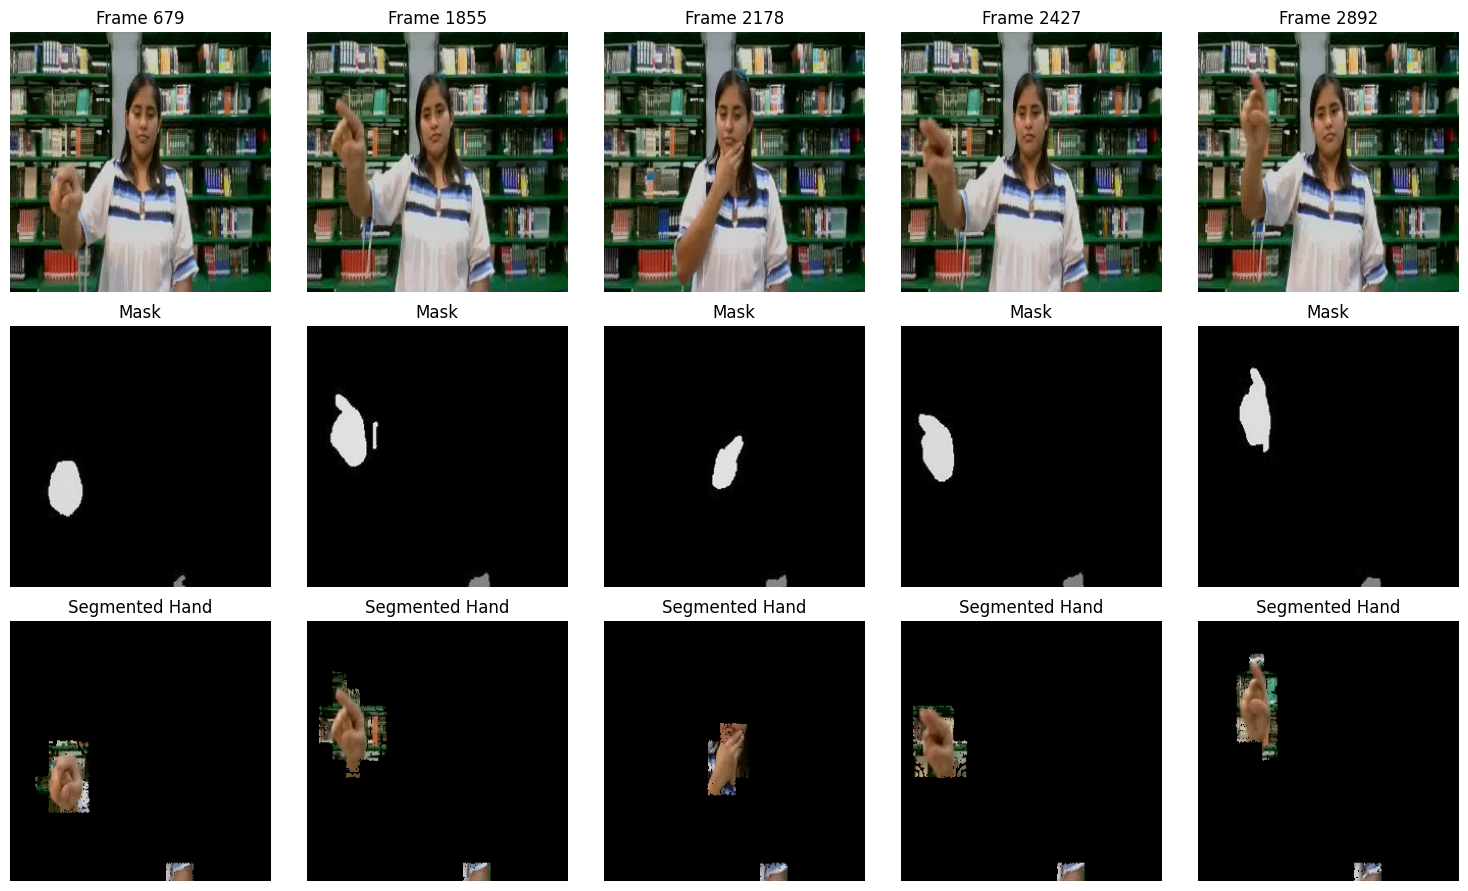

In [5]:
# --- Paths ---
videos_dir = os.path.join(ipn_path, "videos/videos")  # raw video files
seg_dir = os.path.join(seg_path, "segment/segment")   # segmentation sequences

# --- 1. List actual segmentation sequence folders ---
seg_sequences = [d for d in os.listdir(seg_dir) if os.path.isdir(os.path.join(seg_dir, d))]
print("Segmentation sequences available:", seg_sequences[:10])

if not seg_sequences:
    raise ValueError("No segmentation sequences found!")

# --- 2. Pick a random segmentation sequence ---
seq_name = random.choice(seg_sequences)
print("Selected sequence:", seq_name)

# --- 3. Find the corresponding video ---
video_file = seq_name + ".avi"
video_path = os.path.join(videos_dir, video_file)
if not os.path.exists(video_path):
    raise ValueError(f"Video {video_file} not found in videos folder!")

# --- 4. Extract a few frames from the video ---
cap = cv2.VideoCapture(video_path)
frames = []
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Pick 5 random frames
sample_indices = sorted(random.sample(range(frame_count), min(5, frame_count)))

idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break
    if idx in sample_indices:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        # Resize frame to 256x256
        frame_rgb = cv2.resize(frame_rgb, (256, 256))
        frames.append(frame_rgb)
    idx += 1
cap.release()
print(f"Extracted {len(frames)} frames from {video_file}")

# --- 5. Load corresponding segmentation masks ---
mask_seq_path = os.path.join(seg_dir, seq_name)
mask_files = sorted(os.listdir(mask_seq_path))
masks = []
for i in sample_indices:
    m = Image.open(os.path.join(mask_seq_path, mask_files[i])).convert("L")
    # Resize mask to 256x256
    m = m.resize((256, 256))
    mask_array = np.array(m)
    masks.append(mask_array)

# --- 5b. Print shapes for verification ---
for i, (f, m) in enumerate(zip(frames, masks)):
    print(f"Frame {i} shape: {f.shape}, Mask {i} shape: {m.shape}")

# --- 6. Display frames, masks, and segmented hands ---
plt.figure(figsize=(15, 9))
for i, (f, m) in enumerate(zip(frames, masks)):
    # Original frame
    plt.subplot(3, len(frames), i + 1)
    plt.imshow(f)
    plt.title(f"Frame {sample_indices[i]}")
    plt.axis("off")

    # Mask
    plt.subplot(3, len(frames), len(frames) + i + 1)
    plt.imshow(m, cmap='gray')
    plt.title("Mask")
    plt.axis("off")

    # Segmented hand
    segmented = f.copy()
    segmented[m == 0] = 0  # zero out background
    plt.subplot(3, len(frames), 2*len(frames) + i + 1)
    plt.imshow(segmented)
    plt.title("Segmented Hand")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [6]:
def read_annotations(path):
    with open(path, 'r') as f:
        annots = []
        for idx, line in enumerate(f):
            if idx > 0:
                # Parse annotations and convert frame info into ints
                info = line.split(',')
                for i in range(2, len(info)):
                    info[i] = int(info[i])
                annots.append(info)
    return annots

In [15]:
class IPNDataPreProcessor:
    def __init__(self, annots, vid_path, seg_dir, transform = None):
        self.videos_path = vid_path
        self.seg_path = seg_dir

        self.annots = annots
        self.n = len(annots)
        self.videos_path = vid_path
        self.annots = annots
        self.transform = transform

        # Constants
        self.min_frames = 5
        self.num_frames = 210

        self.TARGET_SIZE = (256, 256)


    def __len__(self):
        return len(self.annots)

    def get_frames(self, video_name, start_frame, end_frame):
        video_path = os.path.join(self.videos_path, video_name + ".avi")


        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        if not cap.isOpened():
            raise FileNotFoundError(f"Video file not found: {video_path}")

        frames = []
        masks = []

        for frame_i in range(start_frame, end_frame):

            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mask_idx = frame_i - start_frame + 1
            mask_file = f"{video_name}_{mask_idx:06d}.jpg"
            mask_full_path = os.path.join(self.seg_path, video_name, mask_file)

            if not os.path.exists(mask_full_path):
                raise FileNotFoundError(mask_full_path)

            mask = cv2.imread(mask_full_path, cv2.IMREAD_GRAYSCALE)

            # resize frame sizes to match
            if frame.shape[:2] != mask.shape[:2]:
                frame = cv2.resize(frame, self.TARGET_SIZE)
                mask = cv2.resize(mask, self.TARGET_SIZE, interpolation=cv2.INTER_NEAREST)

            frames.append(frame)
            masks.append(mask)

        cap.release()

        return frames, masks

    def __getitem__(self, idx):
        info = self.annots[idx]
        video_name, label, label_id, start_frame, end_frame, num_frames = info
        frames, masks = self.get_frames(video_name, start_frame, end_frame)

        # # Pad/truncate to fixed length
        frames = self.pad_sequence(frames, self.num_frames)
        masks = self.pad_sequence(masks, self.num_frames)

        # Convert to tensors
        frames = torch.tensor(np.stack(frames)).permute(0,3,1,2).float() / 255.0
        masks = torch.tensor(np.stack(masks)).byte()

        return frames, masks, label_id

    def pad_sequence(self, seq, target_len):
        seq_len = len(seq)
        if seq_len >= target_len:
            return seq[:target_len]

        pad_item = np.zeros_like(seq[0])
        padding = [pad_item.copy() for _ in range(target_len - seq_len)]
        return seq + padding


/tmp/ipython-input-4247044705.py:43: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,4))


torch.Size([1, 210, 3, 256, 256]) torch.Size([1, 210, 256, 256]) tensor([12])


<Figure size 1600x400 with 0 Axes>

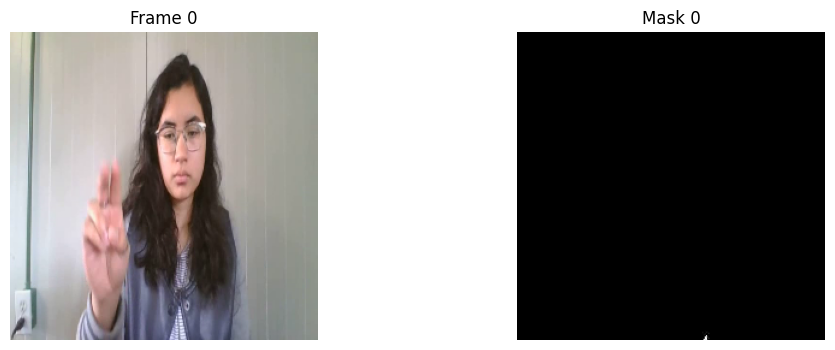

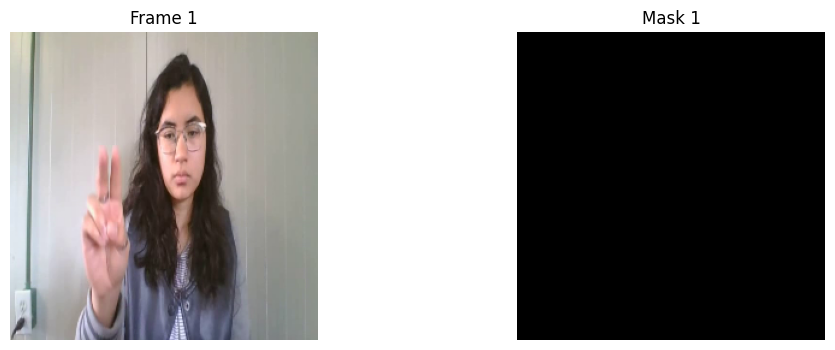

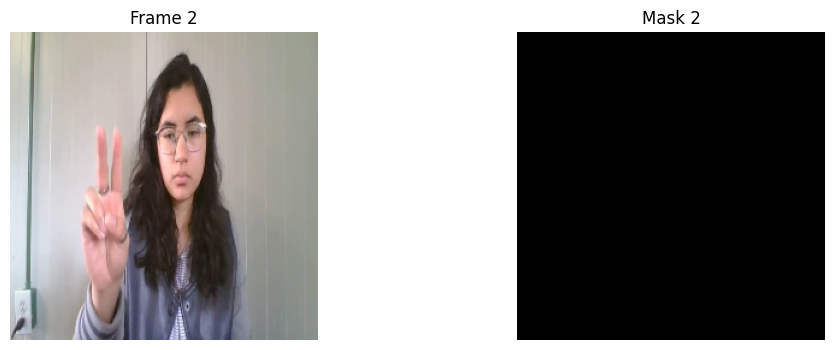

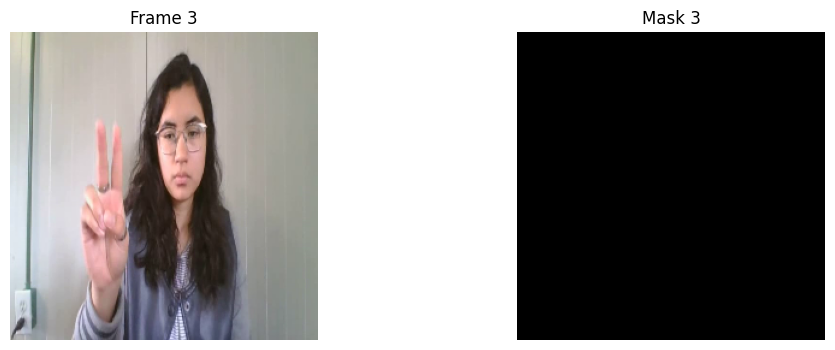

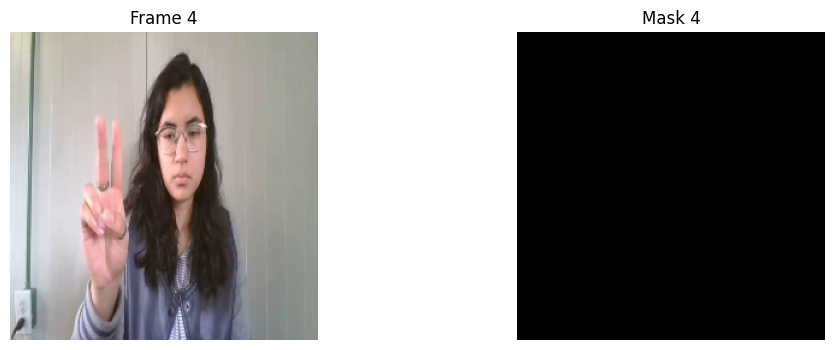

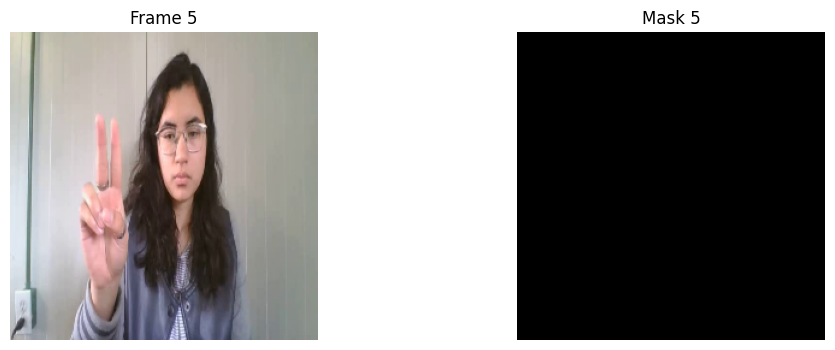

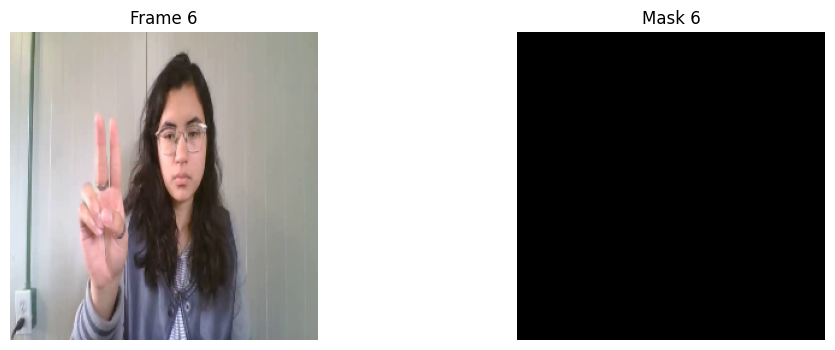

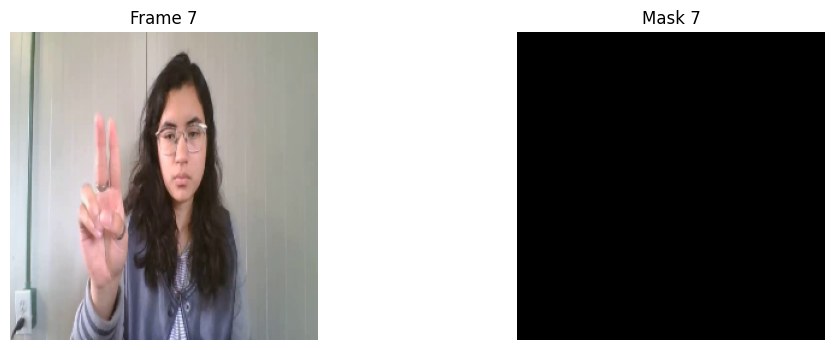

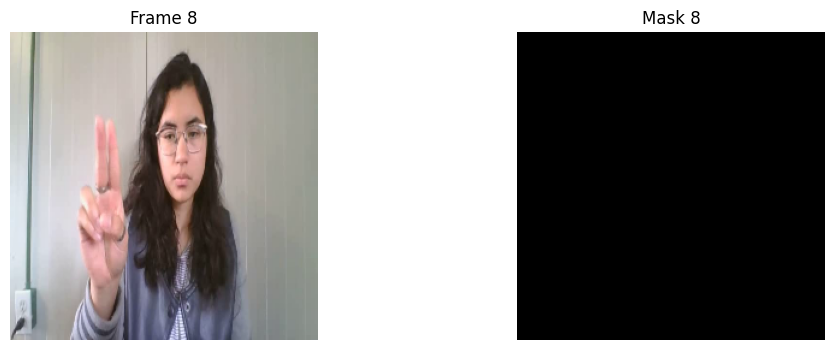

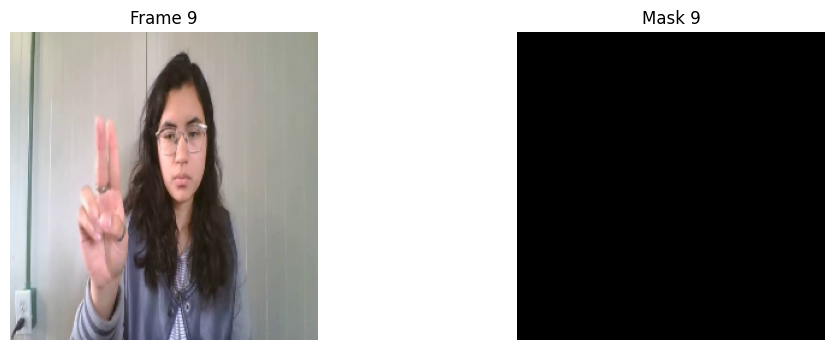

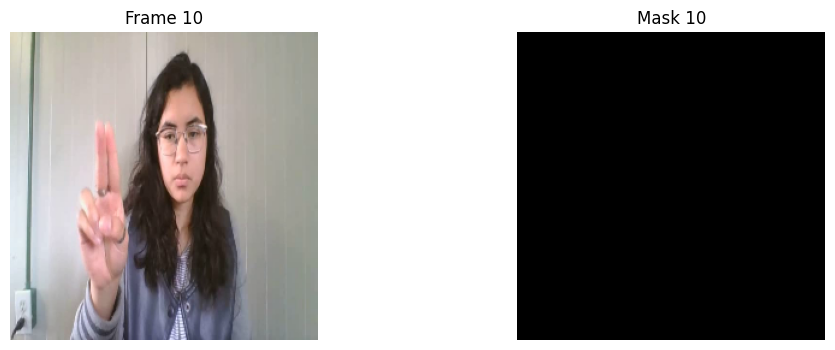

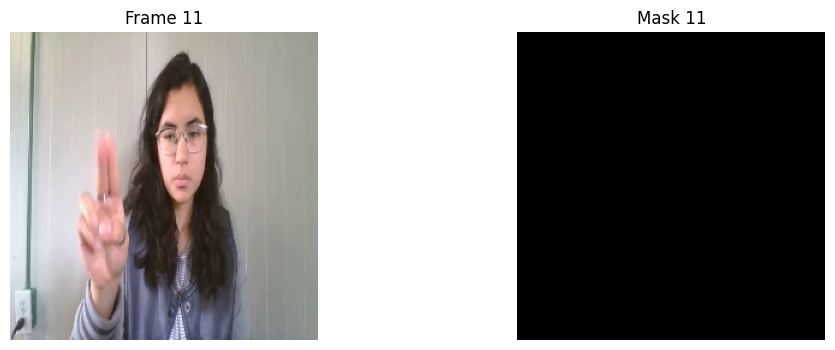

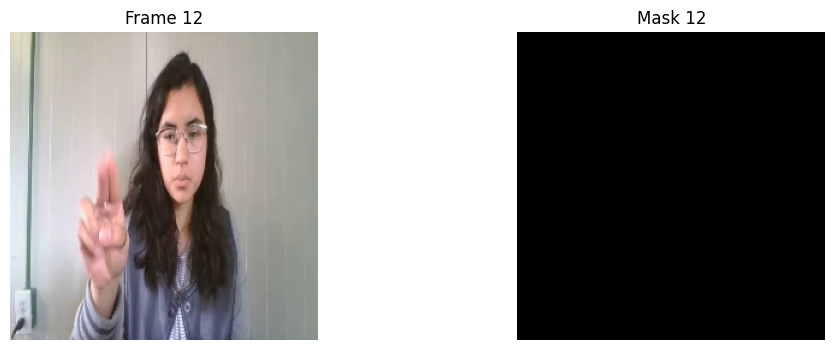

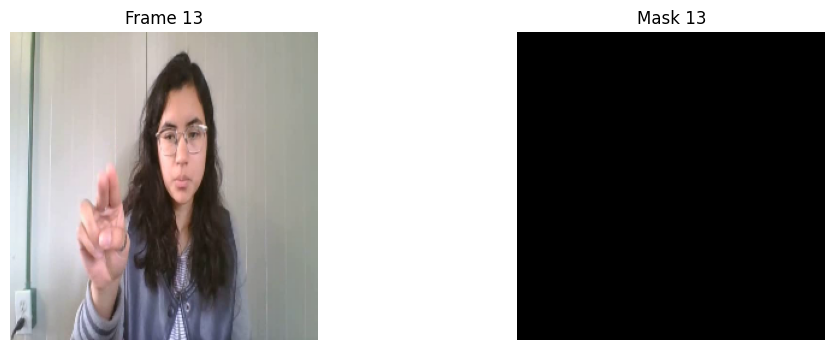

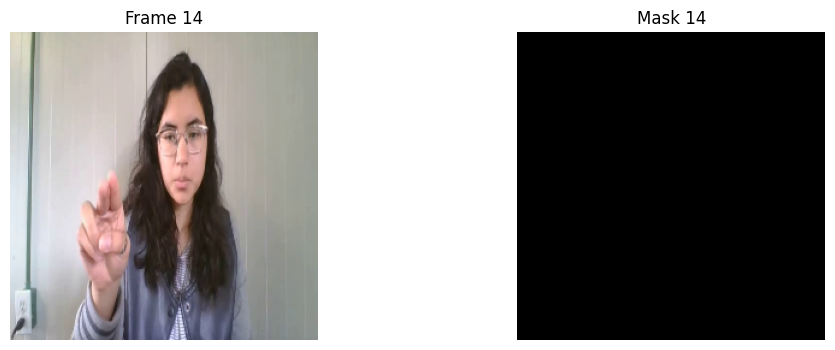

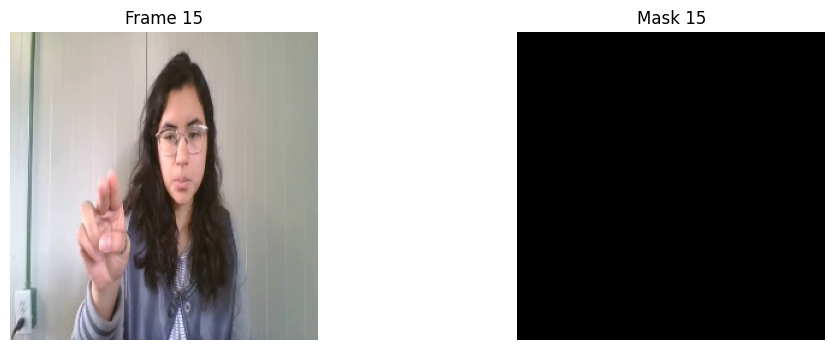

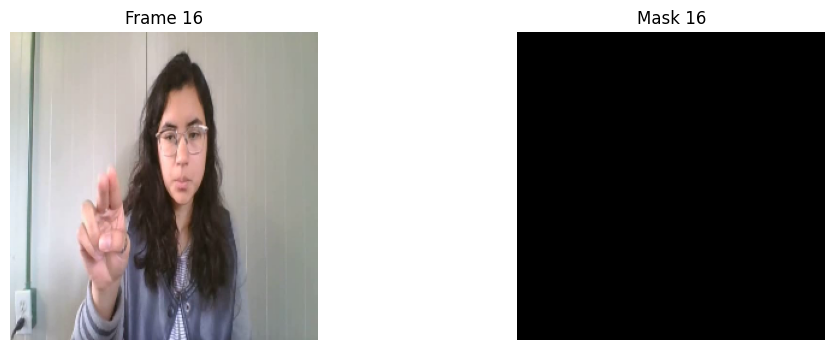

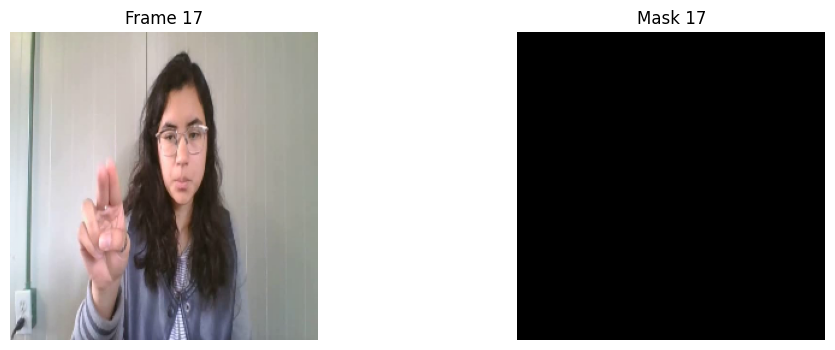

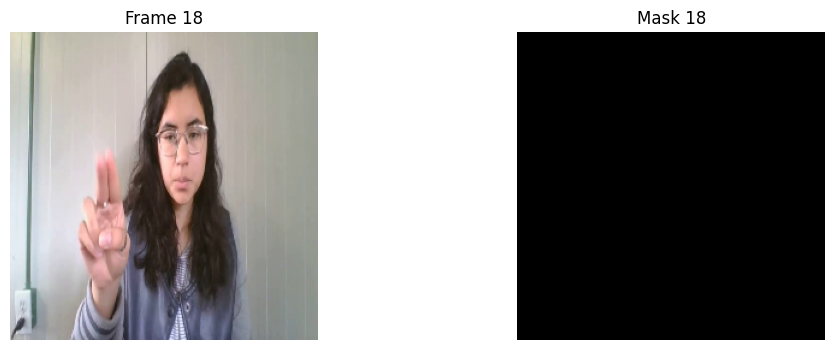

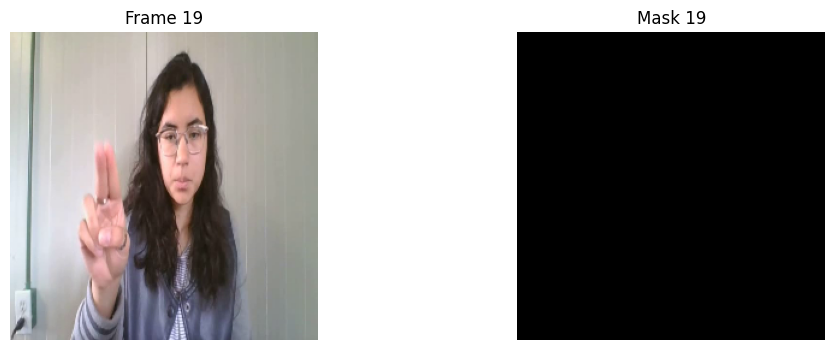

In [16]:
# -----------------------------
# 1. SETUP PATHS
# -----------------------------
videos_dir = os.path.join(ipn_path, "videos/videos")
seg_dir    = os.path.join(seg_path, "segment/segment")

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# 2. DATA
# -----------------------------
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor()
])


annotations_path = os.path.join(ipn_path, "annotations/annotations")

train_annots = read_annotations(os.path.join(annotations_path, "Annot_TrainList.txt"))

train_dataset = IPNDataPreProcessor(
    train_annots,
    videos_dir,
    seg_dir,
    transform=transform,
)

loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

plt.figure(figsize=(16,4))

# Print the input and output shapes and label
for img, mask, label in loader:
    # img:  [B, S, 3, 256, 256]
    # mask: [B, S, 256, 256]
    img_seq = img[0]      # [S, 3, 256, 256]
    mask_seq = mask[0]    # [S, 256, 256]
    for i in range(20):
      frame0 = img_seq[i]   # [3, 256, 256]
      mask0  = mask_seq[i]  # [256, 256]

      plt.figure(figsize=(12,4))

      plt.subplot(1,2,1)
      plt.imshow(frame0.permute(1,2,0))
      plt.title(f"Frame {i}")
      plt.axis("off")

      plt.subplot(1,2,2)
      plt.imshow(mask0, cmap='gray')
      plt.title(f"Mask {i}")
      plt.axis("off")

    print(img.shape, mask.shape, label)
    break



In [9]:
# --- CNN Encoder ---
class CNNEncoder(nn.Module):
    def __init__(self, out_features=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 256->128
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 128->64
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# 64->32
            nn.ReLU(),
            nn.Conv2d(128, out_features, kernel_size=3, stride=2, padding=1), # 32->16
            nn.ReLU()
        )

    def forward(self, x):
        return self.encoder(x)  # [B, out_features, H', W']

# --- CNN Decoder ---
class CNNDecoder(nn.Module):
    def __init__(self, hidden_size=1024, output_channels=1, Hf=16, Wf=16):
        super().__init__()
        self.fc = nn.Linear(hidden_size, 128*Hf*Wf)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), #16->32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  #32->64
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  #64->128
            nn.ReLU(),
            nn.ConvTranspose2d(16, output_channels, kernel_size=4, stride=2, padding=1), #128->256
        )
        self.Hf = Hf
        self.Wf = Wf

    def forward(self, x):
        B, S, H = x.shape
        x = self.fc(x)               # [B*S, 128*Hf*Wf]
        x = x.reshape(B*S, 128, self.Hf, self.Wf)
        x = self.decoder(x)
        x = x.reshape(B, S, 256, 256)
        return x

# --- Full RNN Video Model ---
class RNNVideoModel(nn.Module):
    def __init__(self, sequence_length=210):
        super().__init__()
        self.encoder = CNNEncoder(out_features=128)
        self.sequence_length = sequence_length
        self.rnn = nn.LSTM(
            input_size=128*16*16,
            hidden_size=1024,
            num_layers=2,
            batch_first=True
        )
        self.decoder = CNNDecoder(hidden_size=1024, Hf=16, Wf=16)

    def forward(self, x):
        B, S, C, H, W = x.shape
        x_enc = x.reshape(B*S, C, H, W)      # Flatten batch and sequence
        features = self.encoder(x_enc)     # [B*S, F, Hf, Wf]
        F, Hf, Wf = features.shape[1:]
        features = features.reshape(B, S, F*Hf*Wf)  # [B, S, F*Hf*Wf]

        rnn_out, _ = self.rnn(features)   # [B, S, hidden_size]
        out = self.decoder(rnn_out)       # [B, S, 256, 256]
        return out

In [10]:
# Get training dataset

dataset_size = len(train_dataset)
sub_size = dataset_size // 5

# Optionally, fix random seed for reproducibility
torch.manual_seed(42)

# Randomly split dataset
# only use a small portion of the data to make training faster
subset, _ = random_split(train_dataset, [sub_size, dataset_size - sub_size])

val_fraction = 0.2  # 20% of data for validation
val_size = int(sub_size * val_fraction)
train_size = sub_size - val_size
train_dataset, val_dataset = random_split(subset, [train_size, val_size])

batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [11]:
# load model and save path
model = RNNVideoModel()
model.to(device)

save_path = os.path.join(base_dir, "models", "hand_seg_model_video_2.pth")

TRAIN_NEW_MODEL = True   # ⬅ set True to train, False to load

if TRAIN_NEW_MODEL:
    epochs = 3
    lr = 1e-3

    # criterion = nn.BCELoss()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        i = 0
        for imgs, masks, _ in train_loader:
            imgs, masks = imgs.to(device), masks.to(device)

            preds = model(imgs)
            # print(preds.min().item(), preds.max().item())
            masks = (masks > 0).float().contiguous()
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            i+=1
            print(i/len(train_loader), end='\r')

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    # Save trained model
    plt.figure(figsize=(6,4))
    plt.plot(range(1, epochs+1), loss_history, marker='o')
    plt.title("Training Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()
    torch.save(model.state_dict(), save_path)
    print(f"✅ Saved trained model to: {save_path}")

else:
    # Load existing model
    print("📂 Loading model from storage...")

    if not os.path.exists(save_path):
        raise FileNotFoundError(
            f"The file {save_path} does NOT exist.\n"
            f"Set TRAIN_NEW_MODEL = True to train a new model first."
        )

    model.load_state_dict(torch.load(save_path, map_location=device))
    model.eval()

    print("✅ Loaded saved model successfully.")

KeyboardInterrupt: 

In [ ]:
model.eval()
test_loss = 0
criterion = nn.BCEWithLogitsLoss()

with torch.no_grad():
    for imgs, masks, _ in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        preds = model(imgs)
        masks_proc = (masks > 0).float().contiguous()

        loss = criterion(preds, masks_proc)
        test_loss += loss.item()

avg_test_loss = test_loss / len(val_loader)

print(f"FINAL TEST LOSS: {avg_test_loss:.4f}")

In [ ]:
def visualize_sequence(imgs, masks=None, preds=None, seq_idx=0, num_frames=8):
    """
    imgs:  [B, S, 3, H, W]
    masks: [B, S, H, W]
    preds: [B, S, H, W] (logits)
    """

    imgs = imgs.cpu()
    if masks is not None:
        masks = masks.cpu()
    if preds is not None:
        preds = torch.sigmoid(preds).cpu()  # convert logits → probabilities

    B, S = imgs.shape[:2]
    num_frames = min(num_frames, S)

    fig, axes = plt.subplots(num_frames, 3 if preds is not None else 2, figsize=(12, num_frames * 3))

    if num_frames == 1:
        axes = [axes]

    for i in range(num_frames):
        # Image
        axes[i][0].imshow(imgs[seq_idx, i].permute(1, 2, 0))
        axes[i][0].set_title(f"Frame {i}")
        axes[i][0].axis("off")

        # Ground truth mask
        if masks is not None:
            axes[i][1].imshow(masks[seq_idx, i], cmap="gray")
            axes[i][1].set_title("Mask")
            axes[i][1].axis("off")

        # Prediction
        if preds is not None:
            axes[i][2].imshow(preds[seq_idx, i], cmap="gray")
            axes[i][2].set_title("Prediction")
            axes[i][2].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    imgs, masks, _ = next(iter(train_loader))
    imgs = imgs.to(device)
    masks = masks.to(device)
    preds = model(imgs)

visualize_sequence(imgs, masks, preds, seq_idx=0, num_frames=10)
